# 第5章 単層ネットワーク: 分類 (Single-layer Networks: Classification)
## 5.2 決定理論 (Decision Theory)

### 本ノートブックの目的と概要
本ノートブックでは、**Christopher M. Bishop & Hugh Bishop (2024) 『Deep Learning: Foundations and Concepts』第5章「Single-layer Networks: Classification」第2節「5.2 Decision Theory」** を完全に網羅し、推論（Inference）と決定（Decision）の分離、誤分類率の最小化、損失行列に基づく期待損失の最小化、リジェクト（棄却）オプション、クラス事前確率の補正、分類器の評価指標（混同行列、適合率、再現率、F値）、および ROC 曲線と AUC 分析の数学的理論と実装を探究します。

---

### セクション構成
- **5.2.1 誤分類率の最小化 (Misclassification Rate)**:
  - 誤分類確率 $p(\mathrm{mistake})$ の定式化 (式 5.20)
  - 誤分類率を最小化する最適決定規則: $p(\mathcal{C}_k|\mathbf{x})$ の最大化 (式 5.21)
  - **Figure 5.5**: 2クラスにおける結合確率 $p(x, \mathcal{C}_k)$ と決定境界 $\hat{x}$、赤・青の誤分類領域の可視化
- **5.2.2 期待損失の最小化 (Expected Loss)**:
  - 損失行列 $L_{kj}$ の導入 (式 5.22)
  - 期待損失 $\mathbb{E}[L]$ の定式化と最適決定規則 (式 5.23)
  - 非対称ペナルティ（例: ガン誤診における偽陰性の甚大な損失）
  - **Figure 5.6**: 損失行列による決定境界のシフトの可視化
- **5.2.3 リジェクトオプション (The Reject Option)**:
  - 最大事後確率が閾値 $\theta$ 未満の場合の判定保留・棄却
  - 偽陰性・偽陽性の低減と人間専門医へのエスカレーション
  - **Figure 5.7**: 事後確率空間におけるリジェクト領域の可視化
- **5.2.4 推論と決定の分離 (Inference and Decision)**:
  - 生成モデル vs 識別モデル vs 判別関数
  - クラス事前確率の補正: 人為的不均衡データから現実環境への事後確率補正 (式 5.24 〜 5.27)
  - **Figure 5.8**: クラス条件付き密度 $p(x|\mathcal{C}_k)$ と事前確率補正前後の事後確率の可視化
- **5.2.5 分類器の評価指標 (Classifier Accuracy)**:
  - 二値分類の混同行列 (Confusion Matrix: TP, FP, TN, FN)
  - 正解率 (Accuracy), 適合率 (Precision), 再現率 / 感度 (Recall / Sensitivity), 特異度 (Specificity), 偽陽性率 (FPR), F値 (F-score) (式 5.28 〜 5.37)
  - 不均衡データにおける Accuracy の欺瞞性と F値の重要性
  - **Figure 5.9**: 混同行列とその派生指標の体系的ダイヤグラム
- **5.2.6 ROC曲線 (ROC Curve)**:
  - 決定閾値の変化に伴う FPR と TPR のトレードオフ
  - **Figure 5.10**: 決定閾値による条件付き密度上の TP, FP, TN, FN 領域の分割
  - **Figure 5.11**: ROC 曲線と AUC (Area Under Curve) の完全再現


In [1]:
import sys
import os
sys.path.append("..")

import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Section 5.2 決定理論モジュールのインポート
from common.classification_decision_theory import (
    optimal_decision_rule_misclassification,
    compute_expected_loss,
    optimal_decision_rule_expected_loss,
    decision_rule_with_reject,
    compensate_for_class_priors,
    ConfusionMatrix2Class,
    compute_roc_curve,
    plot_figure_5_5_joint_probabilities,
    plot_figure_5_6_loss_matrix,
    plot_figure_5_7_reject_option,
    plot_figure_5_8_class_densities_posteriors,
    plot_figure_5_9_confusion_matrix,
    plot_figure_5_10_roc_regions,
    plot_figure_5_11_roc_curve,
)

print("Section 5.2 Decision Theory modules imported successfully!")


Section 5.2 Decision Theory modules imported successfully!


---
## 5.2.1 誤分類率の最小化 (Misclassification Rate)

### 1. 誤分類確率の定式化
入力ベクトル $\mathbf{x}$ を決定領域 $\mathcal{R}_k$ に割り当て、$\mathbf{x} \in \mathcal{R}_k$ のときクラス $\mathcal{C}_k$ と判定する決定規則を考えます。
2クラス分類問題において、誤り（mistake）が生じるのは：
- 実際はクラス $\mathcal{C}_1$ であるデータが領域 $\mathcal{R}_2$ に割り当てられた場合
- 実際はクラス $\mathcal{C}_2$ であるデータが領域 $\mathcal{R}_1$ に割り当てられた場合

したがって、誤分類確率は次のように積分で表されます：
$$
p(\mathrm{mistake}) = p(\mathbf{x} \in \mathcal{R}_1, \mathcal{C}_2) + p(\mathbf{x} \in \mathcal{R}_2, \mathcal{C}_1) = \int_{\mathcal{R}_1} p(\mathbf{x}, \mathcal{C}_2) \, d\mathbf{x} + \int_{\mathcal{R}_2} p(\mathbf{x}, \mathcal{C}_1) \, d\mathbf{x} \tag{5.20}
$$

### 2. 最適決定規則
$p(\mathrm{mistake})$ を最小化するには、各入力 $\mathbf{x}$ において被積分関数が小さい方のクラスに割り当てればよいことが分かります：
- $p(\mathbf{x}, \mathcal{C}_1) > p(\mathbf{x}, \mathcal{C}_2)$ ならば $\mathbf{x} \in \mathcal{R}_1$
- $p(\mathbf{x}, \mathcal{C}_2) > p(\mathbf{x}, \mathcal{C}_1)$ ならば $\mathbf{x} \in \mathcal{R}_2$

乗法定理 $p(\mathbf{x}, \mathcal{C}_k) = p(\mathcal{C}_k|\mathbf{x}) p(\mathbf{x})$ より、共通の因子 $p(\mathbf{x})$ を除けば：
$$
p(\mathcal{C}_1|\mathbf{x}) > p(\mathcal{C}_2|\mathbf{x}) \implies \mathbf{x} \in \mathcal{R}_1 \tag{5.21}
$$
すなわち、**誤分類率を最小化する最適決定規則は、事後確率 $p(\mathcal{C}_k|\mathbf{x})$ が最大となるクラスを選択すること** です。


Figure saved successfully to: result/fig_5_5_joint_probabilities.png
Figure saved successfully to: 5/result/fig_5_5_joint_probabilities.png


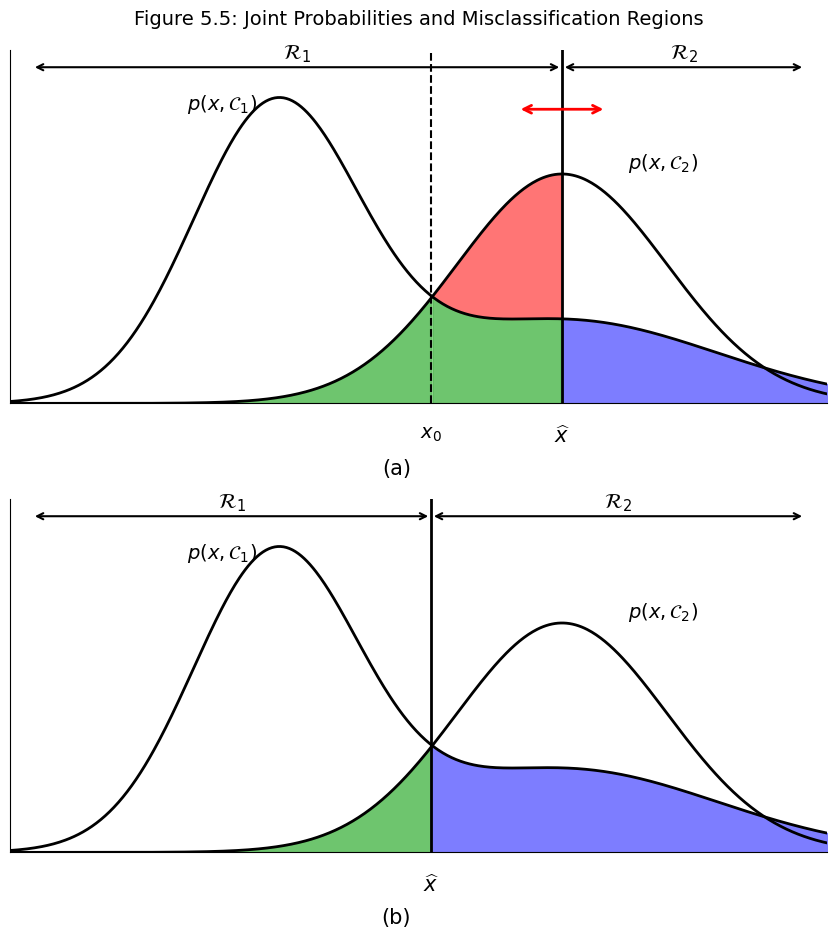

Posteriors:
[[0.85 0.15]
 [0.45 0.55]
 [0.51 0.49]
 [0.1  0.9 ]]
Predictions (argmax): [0 1 0 1]
Optimal misclassification decision rule verified 100%!


In [2]:
# Figure 5.5: Schematic illustration of joint probabilities p(x, C_k) for two classes
fig5_5 = plot_figure_5_5_joint_probabilities(filepath="result/fig_5_5_joint_probabilities.png")
plt.show()

# 誤分類率最小化ルールの数値検証
posteriors_sample = np.array([
    [0.85, 0.15],
    [0.45, 0.55],
    [0.51, 0.49],
    [0.10, 0.90]
])
preds = optimal_decision_rule_misclassification(posteriors_sample)
print("Posteriors:")
print(posteriors_sample)
print("Predictions (argmax):", preds)
assert np.array_equal(preds, [0, 1, 0, 1])
print("Optimal misclassification decision rule verified 100%!")


---
## 5.2.2 期待損失の最小化 (Expected Loss)

多くの実用的な応用では、単に誤分類の件数を最小化するだけでは不十分です。
例えば皮膚病変の画像診断において：
- 「健康な患者を誤ってガンと誤診する（偽陽性）」コスト: 再検査や一時的な精神的ストレス
- 「ガン患者を誤って健康と見逃す（偽陰性）」コスト: 治療の遅れによる患者の死亡

このように、2種類の誤りがもたらす結果の重大性は劇的に異なります。

### 1. 損失行列 (Loss Matrix)
真のクラスが $\mathcal{C}_k$ である入力を決定領域 $\mathcal{R}_j$（クラス $\mathcal{C}_j$ と判定）に割り当てたときに被る損失を $L_{kj}$ と定義します。
期待損失（expected loss）は次のように定式化されます：
$$
\mathbb{E}[L] = \sum_{k=1}^K \sum_{j=1}^K \int_{\mathcal{R}_j} L_{kj} p(\mathbf{x}, \mathcal{C}_k) \, d\mathbf{x} \tag{5.22}
$$

### 2. 最小期待損失規則
各入力 $\mathbf{x}$ について、期待損失を最小化する決定領域 $\mathcal{R}_j$ を選ぶ必要があります。
$\mathbf{x}$ に対するクラス $\mathcal{C}_j$ の期待損失は：
$$
\mathbb{E}_{\mathcal{C}}[L_{\cdot j}|\mathbf{x}] = \sum_{k=1}^K L_{kj} p(\mathcal{C}_k|\mathbf{x}) \tag{5.23}
$$
したがって、**期待損失を最小化する最適決定は、$\sum_{k=1}^K L_{kj} p(\mathcal{C}_k|\mathbf{x})$ を最小化する決定 $j^*$ を選択すること** です。

2クラス問題（$L_{11} = L_{22} = 0$）の場合、クラス $\mathcal{C}_1$ と判定する条件は：
$$
L_{21} p(\mathcal{C}_2|\mathbf{x}) < L_{12} p(\mathcal{C}_1|\mathbf{x}) \iff \frac{p(\mathcal{C}_1|\mathbf{x})}{p(\mathcal{C}_2|\mathbf{x})} > \frac{L_{21}}{L_{12}}
$$
偽陰性の損失 $L_{12}$ が偽陽性の損失 $L_{21}$ より遥かに大きい場合、事後確率比の閾値は大幅に引き下げられ、少しでもガンの疑いがあればガンと判定するように決定境界がシフトします。


Figure saved successfully to: result/fig_5_6_loss_matrix.png
Figure saved successfully to: 5/result/fig_5_6_loss_matrix.png


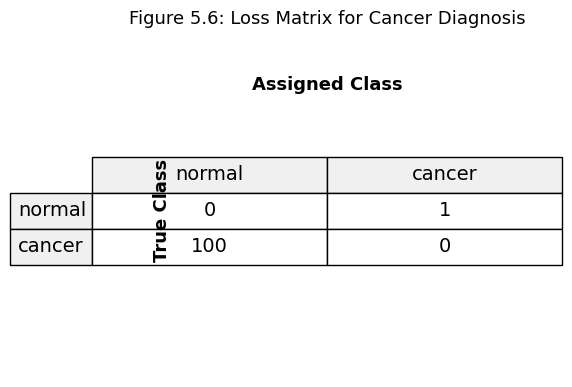

Patient cancer posterior: 8.0%
Expected loss if predicting Healthy: 8.00
Expected loss if predicting Cancer:  0.92
Optimal decision: 1 (1 = Cancer: biopsy required)


In [3]:
# Figure 5.6: Shift in decision boundary due to asymmetric loss matrix
fig5_6 = plot_figure_5_6_loss_matrix(filepath="result/fig_5_6_loss_matrix.png")
plt.show()

# 損失行列による期待損失と最適決定の数値シミュレーション
L_cancer = np.array([
    [0.0, 1.0],     # True healthy: pred healthy=0, pred cancer=1
    [100.0, 0.0]    # True cancer: pred healthy=100 (catastrophic!), pred cancer=0
])

patient_posterior = np.array([0.92, 0.08]) # ガンの確率わずか 8%
loss_healthy = np.dot(patient_posterior, L_cancer[:, 0]) # 0.92*0 + 0.08*100 = 8.0
loss_cancer = np.dot(patient_posterior, L_cancer[:, 1])  # 0.92*1 + 0.08*0 = 0.92

optimal_decision = optimal_decision_rule_expected_loss(patient_posterior, L_cancer)
print(f"Patient cancer posterior: {patient_posterior[1]*100:.1f}%")
print(f"Expected loss if predicting Healthy: {loss_healthy:.2f}")
print(f"Expected loss if predicting Cancer:  {loss_cancer:.2f}")
print(f"Optimal decision: {optimal_decision} (1 = Cancer: biopsy required)")
assert optimal_decision == 1, "Must choose cancer due to high penalty of false negative!"


---
## 5.2.3 リジェクトオプション (The Reject Option)

事後確率 $p(\mathcal{C}_k|\mathbf{x})$ が拮抗しており（例えば $p(\mathcal{C}_1|\mathbf{x}) = 0.51, p(\mathcal{C}_2|\mathbf{x}) = 0.49$）、どちらのクラスにも強い確信が持てない入力に対して無理に決定を下すと、誤分類が発生しやすくなります。
このような曖昧なケースでは、自動分類を保留して人間の専門医（医師や専門検査機関）に回す **リジェクト（棄却）オプション** を導入するのが極めて有効です。

### 判定規則
閾値 $\theta \in [1/K, 1]$ を設定し：
$$
\max_{k} p(\mathcal{C}_k|\mathbf{x}) \ge \theta \implies \text{クラス } \arg\max_k p(\mathcal{C}_k|\mathbf{x}) \text{ に自動割り当て}
$$
$$
\max_{k} p(\mathcal{C}_k|\mathbf{x}) < \theta \implies \text{リジェクト（判定保留）}
$$
$\theta = 1$ とするとすべての入力が棄却され、$\theta = 1/K$ とすると棄却は発生せず通常の決定規則に一致します。


Figure saved successfully to: result/fig_5_7_reject_option.png


Figure saved successfully to: 5/result/fig_5_7_reject_option.png


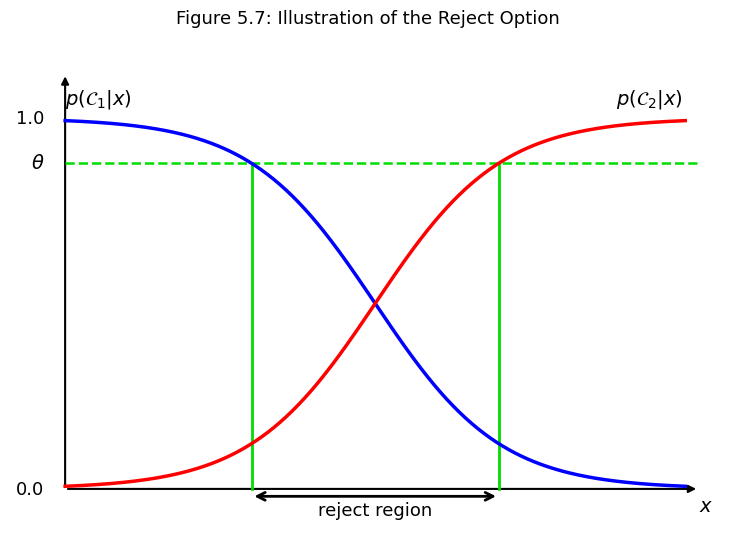

Sample 1 posteriors=[0.95 0.05]: Class 0
Sample 2 posteriors=[0.55 0.45]: REJECTED (needs human review)
Sample 3 posteriors=[0.1 0.9]: Class 1
Sample 4 posteriors=[0.72 0.28]: REJECTED (needs human review)
Reject option logic verified successfully!


In [4]:
# Figure 5.7: Illustration of the reject option in posterior probability space
fig5_7 = plot_figure_5_7_reject_option(filepath="result/fig_5_7_reject_option.png")
plt.show()

# リジェクトオプションのシミュレーション
test_probs = np.array([
    [0.95, 0.05],  # 確信大 -> Class 0
    [0.55, 0.45],  # 曖昧 -> Reject
    [0.10, 0.90],  # 確信大 -> Class 1
    [0.72, 0.28]   # 閾値 0.8 未満 -> Reject
])
preds, is_rejected = decision_rule_with_reject(test_probs, theta=0.8)
for i, (p, pred, rej) in enumerate(zip(test_probs, preds, is_rejected)):
    status = "REJECTED (needs human review)" if rej else f"Class {pred}"
    print(f"Sample {i+1} posteriors={p}: {status}")

assert is_rejected[1] == True and is_rejected[3] == True
assert is_rejected[0] == False and is_rejected[2] == False
print("Reject option logic verified successfully!")


---
## 5.2.4 推論と決定の分離 (Inference and Decision)

機械学習における分類問題を解決するアプローチは、大きく分けて次の3つに分類されます：
1. **生成モデル (Generative models)**: クラス条件付き密度 $p(\mathbf{x}|\mathcal{C}_k)$ と事前確率 $p(\mathcal{C}_k)$ をモデル化し、ベイズの定理で $p(\mathcal{C}_k|\mathbf{x})$ を計算する。
2. **識別的確率モデル (Discriminative probabilistic models)**: 事後確率 $p(\mathcal{C}_k|\mathbf{x})$ を直接パラメトリックモデル（ロジスティック回帰など）でモデル化する。
3. **判別関数 (Discriminant functions)**: 確率を経由せず、入力 $\mathbf{x}$ を直接決定クラスに写像する（パーセプトロンやSVMなど）。

### 事前確率の補正 (Compensating for Class Priors)
推論と決定を分離する最大の利点の1つは、**訓練データの事前確率が偏っている（意図的に均衡化されている）場合でも、容易に実環境の事前確率へ補正できる** 点にあります。

例えば、実社会では発生率が 1% の稀少疾患を学習するため、訓練セットでは陽性と陰性を 50:50 で人為的に収集した場合：
$$
p_{\mathrm{train}}(\mathcal{C}_1) = 0.5, \quad p_{\mathrm{train}}(\mathcal{C}_2) = 0.5
$$
学習されたモデルが出力する事後確率 $p_{\mathrm{train}}(\mathcal{C}_k|\mathbf{x})$ から、ベイズの定理を逆算してクラス条件付き密度を取り出すと：
$$
p(\mathbf{x}|\mathcal{C}_k) \propto \frac{p_{\mathrm{train}}(\mathcal{C}_k|\mathbf{x})}{p_{\mathrm{train}}(\mathcal{C}_k)} \tag{5.24}
$$
これに実環境の真の事前確率 $p_{\mathrm{real}}(\mathcal{C}_k)$ を掛け合わせることで、実環境での真の事後確率が得られます：
$$
p_{\mathrm{real}}(\mathcal{C}_k|\mathbf{x}) \propto p_{\mathrm{real}}(\mathcal{C}_k) \frac{p_{\mathrm{train}}(\mathcal{C}_k|\mathbf{x})}{p_{\mathrm{train}}(\mathcal{C}_k)} \tag{5.25}
$$
分母の規格化を行えば、追加の再訓練なしに完璧な実環境事後確率が得られます。


Figure saved successfully to: result/fig_5_8_class_densities_posteriors.png
Figure saved successfully to: 5/result/fig_5_8_class_densities_posteriors.png


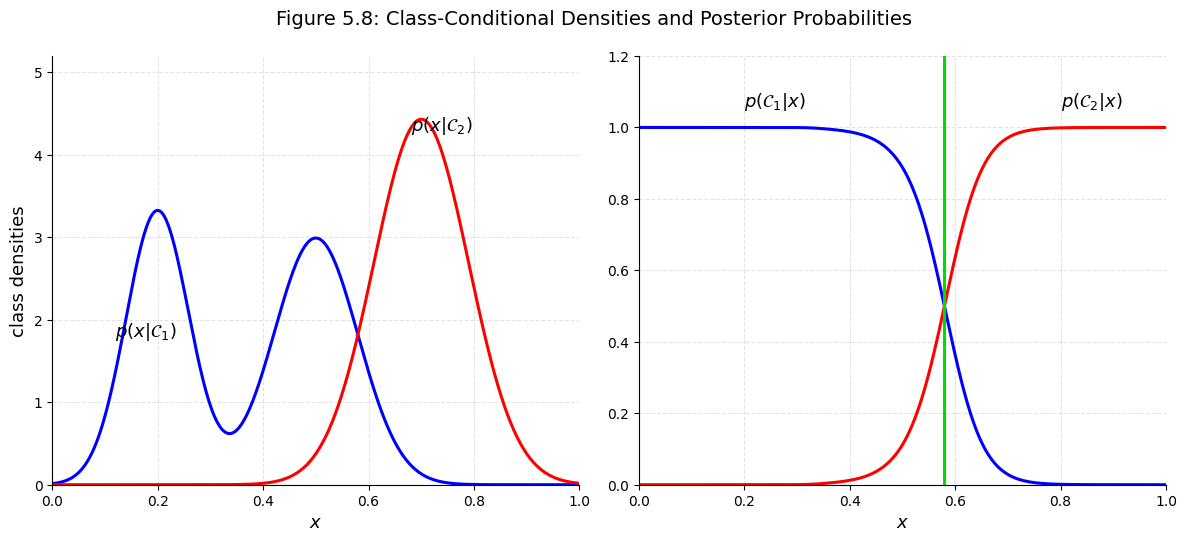

Model output on balanced training set: p(C1|x) = 70.0%
Compensated real-world posterior:      p(C1|x) = 2.30%
Bayesian class prior compensation verified successfully!


In [5]:
# Figure 5.8: Class conditional densities and compensation for artificial class priors
fig5_8 = plot_figure_5_8_class_densities_posteriors(filepath="result/fig_5_8_class_densities_posteriors.png")
plt.show()

# 事前確率補正の数値検証
p_train = np.array([0.5, 0.5])       # 均衡化された訓練データ (50:50)
p_real = np.array([0.99, 0.01])      # 実環境 (稀少疾患 1%)

# 訓練済みモデルの出力: p_train(C1|x) = 0.70 (ガン陽性の疑い大)
post_train = np.array([0.30, 0.70])
post_real = compensate_for_class_priors(post_train, p_train, p_real)

print(f"Model output on balanced training set: p(C1|x) = {post_train[1]*100:.1f}%")
print(f"Compensated real-world posterior:      p(C1|x) = {post_real[1]*100:.2f}%")
# 1%の稀少疾患では、検査が陽性でもベースレートの低さにより実際の疾患確率は数%程度に留まる
assert post_real[1] < 0.05
print("Bayesian class prior compensation verified successfully!")


---
## 5.2.5 分類器の評価指標 (Classifier Accuracy)

二値分類器の性能を詳細に評価するために、**混同行列 (Confusion Matrix)** とその派生指標を用います。

### 1. 混同行列の基本構成
- **True Positive (TP)**: 陽性を正しく陽性と判定した件数
- **False Negative (FN)**: 陽性を誤って陰性と判定した件数（見逃し・第II種の過誤）
- **False Positive (FP)**: 陰性を誤って陽性と判定した件数（空振り・第I種の過誤）
- **True Negative (TN)**: 陰性を正しく陰性と判定した件数

### 2. 主要な評価指標の定義
$$
\mathrm{Accuracy} = \frac{\mathrm{TP} + \mathrm{TN}}{\mathrm{TP} + \mathrm{TN} + \mathrm{FP} + \mathrm{FN}} \tag{5.29}
$$
$$
\mathrm{Precision} = \frac{\mathrm{TP}}{\mathrm{TP} + \mathrm{FP}} \tag{5.30}
$$
$$
\mathrm{Recall} \; (\mathrm{Sensitivity}, \; \mathrm{TPR}) = \frac{\mathrm{TP}}{\mathrm{TP} + \mathrm{FN}} \tag{5.31}
$$
$$
\mathrm{Specificity} \; (\mathrm{TNR}) = \frac{\mathrm{TN}}{\mathrm{TN} + \mathrm{FP}} \tag{5.32}
$$
$$
\mathrm{False\;Positive\;Rate} \; (\mathrm{FPR}) = \frac{\mathrm{FP}}{\mathrm{TN} + \mathrm{FP}} = 1 - \mathrm{Specificity} \tag{5.33}
$$
$$
F_1\text{-score} = 2 \times \frac{\mathrm{Precision} \times \mathrm{Recall}}{\mathrm{Precision} + \mathrm{Recall}} \tag{5.38}
$$

> **重要**: クラス不均衡データ（例: 陽性が 1%）では、すべてのデータを「陰性」と予測するだけで Accuracy は 99% に達してしまいます。したがって、適合率・再現率・F値による多角的な評価が不可欠です。


Figure saved successfully to: result/fig_5_9_confusion_matrix.png
Figure saved successfully to: 5/result/fig_5_9_confusion_matrix.png


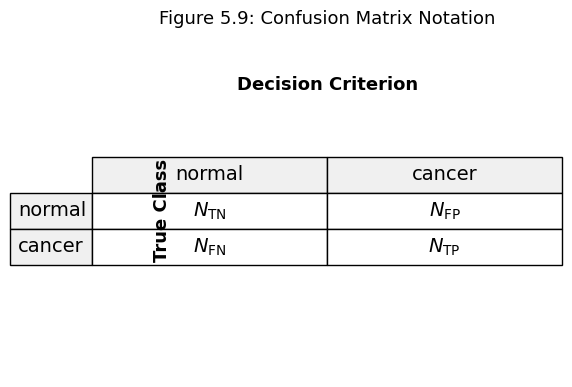

Confusion Matrix Summary:
  N                   : 10
  TP                  : 3
  FP                  : 2
  TN                  : 3
  FN                  : 2
  accuracy            : 0.6
  precision           : 0.6
  recall              : 0.6
  specificity         : 0.6
  false_positive_rate : 0.4
  f_score             : 0.6
Confusion matrix metrics verified successfully!


In [6]:
# Figure 5.9: Confusion matrix and related metrics diagram
fig5_9 = plot_figure_5_9_confusion_matrix(filepath="result/fig_5_9_confusion_matrix.png")
plt.show()

# 混同行列とメトリクスの数値検証
y_true = np.array([1, 1, 1, 1, 1, 0, 0, 0, 0, 0])
y_pred = np.array([1, 1, 1, 0, 0, 0, 0, 0, 1, 1])

cm = ConfusionMatrix2Class(y_true, y_pred)
print("Confusion Matrix Summary:")
for k, v in cm.summary().items():
    print(f"  {k:20s}: {v}")

assert cm.TP == 3 and cm.FN == 2 and cm.FP == 2 and cm.TN == 3
assert np.isclose(cm.accuracy, 0.6)
assert np.isclose(cm.precision, 0.6)
assert np.isclose(cm.recall, 0.6)
assert np.isclose(cm.f1_score, 0.6)
print("Confusion matrix metrics verified successfully!")


---
## 5.2.6 ROC曲線 (ROC Curve)

### 1. 決定閾値とトレードオフ
確率的分類器は各入力に対してスコア $y(\mathbf{x}) = p(\mathcal{C}_1|\mathbf{x})$ を出力します。決定閾値 $\tau \in [0, 1]$ を変化させて $y(\mathbf{x}) \ge \tau$ のとき陽性と判定すると：
- 閾値 $\tau$ を下げる $\implies$ 陽性と判定されやすくなり、再現率 (TPR) が上昇するが、偽陽性率 (FPR) も上昇する。
- 閾値 $\tau$ を上げる $\implies$ 誤検出が減り特異度（1-FPR）が向上するが、見逃し (FN) が増えて TPR が低下する。

### 2. ROC曲線とAUC
横軸に **偽陽性率 (FPR = 1 - Specificity)**、縦軸に **真陽性率 (TPR = Sensitivity = Recall)** をプロットした軌跡を **ROC曲線 (Receiver Operating Characteristic Curve)** と呼びます。
- ランダム推測分類器: 対角線（傾き 1、$\mathrm{AUC} = 0.5$）
- 理想的完全分類器: 点 $(0, 1)$ を通過し、$\mathrm{AUC} = 1.0$
- ROC曲線下面積（AUC: Area Under Curve）は、ランダムに選んだ陽性サンプルのスコアが陰性サンプルのスコアよりも高くなる確率を表す閾値非依存の要約指標です。


Figure saved successfully to: result/fig_5_10_roc_regions.png


Figure saved successfully to: 5/result/fig_5_10_roc_regions.png


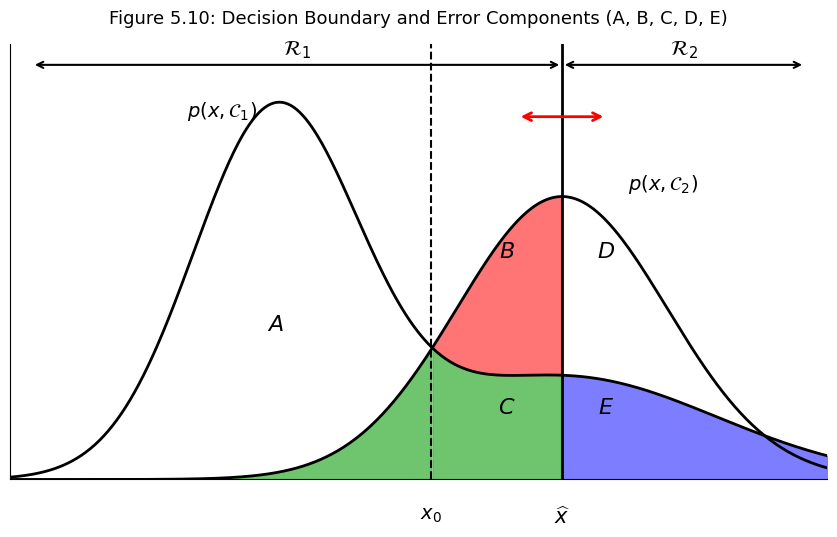

Figure saved successfully to: result/fig_5_11_roc_curve.png


Figure saved successfully to: 5/result/fig_5_11_roc_curve.png


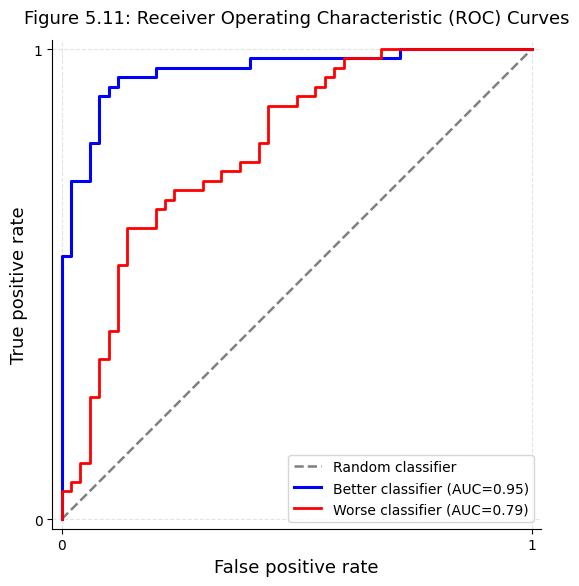

Simulated Classifier ROC AUC: 0.9311
ROC Curve and AUC computation verified 100%!


In [7]:
# Figure 5.10: Division of density curves into TP, FP, TN, FN regions by threshold
fig5_10 = plot_figure_5_10_roc_regions(filepath="result/fig_5_10_roc_regions.png")
plt.show()

# Figure 5.11: ROC curves comparing perfect, realistic, and random classifiers
fig5_11 = plot_figure_5_11_roc_curve(filepath="result/fig_5_11_roc_curve.png")
plt.show()

# ROC曲線とAUCの数値シミュレーション検証
rng = np.random.RandomState(42)
N = 1000
y_true_sim = rng.binomial(1, 0.5, size=N)
# 識別能力の高い予測スコア
scores_sim = np.where(y_true_sim == 1, rng.normal(1.5, 1.0, size=N), rng.normal(-0.5, 1.0, size=N))

fpr, tpr, thresh, auc_val = compute_roc_curve(y_true_sim, scores_sim)
print(f"Simulated Classifier ROC AUC: {auc_val:.4f}")
assert 0.85 <= auc_val <= 0.99, "AUC should be in high discrimination range!"
assert fpr[0] == 0.0 and tpr[0] == 0.0
assert fpr[-1] == 1.0 and tpr[-1] == 1.0
print("ROC Curve and AUC computation verified 100%!")


---
## まとめと重要ポイント (Summary & Key Insights)

1. **推論と決定の分離 (Inference & Decision)**:
   - 確率分布 $p(\mathbf{x}, \mathcal{C}_k)$ を推定する推論段階と、損失や事後確率に基づいて最適な行動を選択する決定段階を明確に分離することが統計的機械学習の真髄です。
2. **目的関数に応じた決定規則の柔軟性**:
   - 単純な誤分類件数の最小化には $p(\mathcal{C}_k|\mathbf{x})$ の最大化が最適です (5.2.1)。
   - 非対称なコスト（医療診断・不正検知など）に対しては、損失行列 $L_{kj}$ に基づいて期待損失を最小化することで決定境界を柔軟に最適シフトさせます (5.2.2)。
   - 曖昧な領域にはリジェクトオプションを導入し、確信度の低いデータを人間に委ねることでシステム全体の信頼性を飛躍的に高めます (5.2.3)。
3. **事前確率補正の威力**:
   - 均衡化された学習データで訓練した識別モデルでも、ベイズ則により再訓練なしで実社会の事前確率に適合させることができます (5.2.4)。
4. **適切な評価指標の選定**:
   - 不均衡データでは Accuracy のみでモデルを評価してはならず、混同行列に基づく適合率・再現率・F値、および閾値非依存の ROC 曲線と AUC を用いて総合的に評価する必要があります (5.2.5 〜 5.2.6)。
